# Random Forest Regression
### Imports

In [47]:
import pandas as pd
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



#### Load and check data

In [48]:
# Load the training and test data
X_train = pd.read_csv('Datasets/alternative_X_train.csv')
X_test = pd.read_csv('Datasets/alternative_X_test.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
y_test = pd.read_csv('Datasets/y_test.csv')


In [49]:
# Ensure the test data has the same columns as the training data
X_test = X_test[X_train.columns]
y_test = y_test[y_train.columns] 

In [50]:
# check the shape of the data
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# check collumn names are identical
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())


y_train = y_train.values.squeeze()  # Flatten if a single column DataFrame
y_test = y_test.values.squeeze()

print(y_train)


Shape of X_train: (404, 217)
Shape of y_train: (404, 10)
Shape of y_test: (101, 10)
X_train columns: ['IMDb rating', 'duration', 'content rating', 'year', 'month', 'genre 1', 'genre 2', 'genre 3', 'writer 1', 'writer 2', 'writer 3', 'star 1', 'star 2', 'star 3', 'director 1', 'director 2', 'director 3', 'title_tfidf_1', 'title_tfidf_2', 'title_tfidf_3', 'title_tfidf_4', 'title_tfidf_5', 'title_tfidf_6', 'title_tfidf_7', 'title_tfidf_8', 'title_tfidf_9', 'title_tfidf_10', 'title_tfidf_11', 'title_tfidf_12', 'title_tfidf_13', 'title_tfidf_14', 'title_tfidf_15', 'title_tfidf_16', 'title_tfidf_17', 'title_tfidf_18', 'title_tfidf_19', 'title_tfidf_20', 'title_tfidf_21', 'title_tfidf_22', 'title_tfidf_23', 'title_tfidf_24', 'title_tfidf_25', 'title_tfidf_26', 'title_tfidf_27', 'title_tfidf_28', 'title_tfidf_29', 'title_tfidf_30', 'title_tfidf_31', 'title_tfidf_32', 'title_tfidf_33', 'title_tfidf_34', 'title_tfidf_35', 'title_tfidf_36', 'title_tfidf_37', 'title_tfidf_38', 'title_tfidf_39', 't

In [51]:
# check if there are missing values or collumns
train_columns = set(X_train.columns)
test_columns = set(X_test.columns)

missing_in_test = train_columns - test_columns
extra_in_test = test_columns - train_columns

print("Missing in X_test:", missing_in_test)
print("Extra in X_test:", extra_in_test)


Missing in X_test: set()
Extra in X_test: set()


## Initialize and train the random forest
### Hyperparameter Tuning

In [52]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Set up GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best parameters found: ", grid_search.best_params_)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.1s
[CV] END ma

## Predict

In [53]:
best_model = grid_search.best_estimator_

# Predict using the best model
y_pred = best_model.predict(X_test)



In [54]:
# final check if shapes match
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)
assert y_test.shape == y_pred.shape, "Shapes of y_test and y_pred must match."


Shape of y_test: (101, 10)
Shape of y_pred: (101, 10)


## Evaluate model

In [56]:
# Calculate the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')

# Calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.2f}')



Mean Absolute Error: 0.22
Mean Squared Error: 0.12
R-squared: -0.10


## Feature Importance Visualisation 

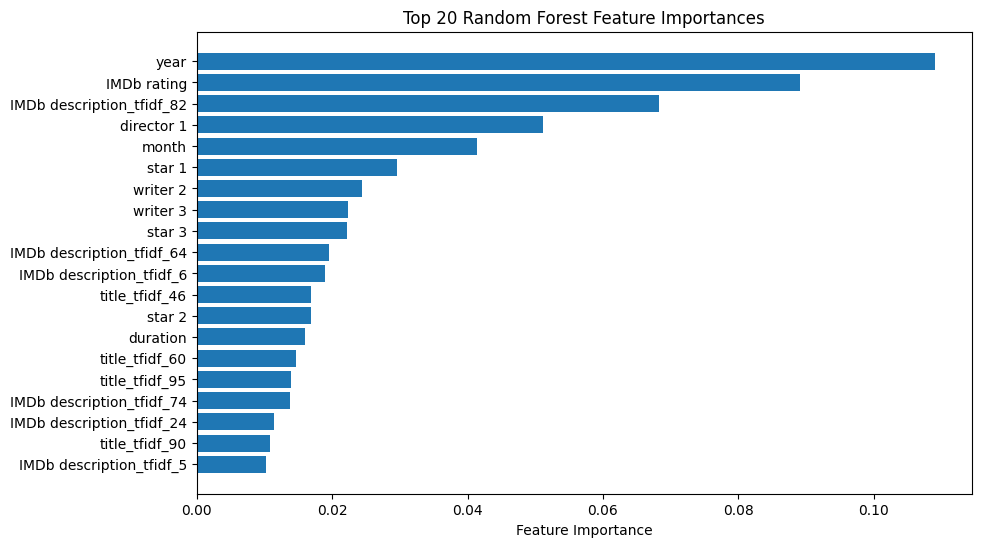

In [57]:
# Get feature importances
importances = best_model.feature_importances_

# Sort the importances in descending order and get the indices of the top 20
sorted_indices = np.argsort(importances)[::-1][:20]  # Top 20

# Create a bar chart for the top 20 features
plt.figure(figsize=(10, 6))
plt.barh(range(20), importances[sorted_indices], align='center')
plt.yticks(range(20), X_train.columns[sorted_indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Random Forest Feature Importances')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.show()
